# TS Dynamic Fit Pipeline

Below, and in order, are all of the needed ways the user can interact with the code and view outputs. 

Please keep in mind that the models used in this notebook are saved under `model registry/examples` and are not updated upon new pipeline runs. 

Many of the variables that are hard coded in this notebook are changable with CLI arguments when running main.py

In [1]:
from src.TSDataLoader import *
# from src.TSDataLoader_old import *
from algs.arima import *
from algs.sarima import *
from algs.lstm import *
from src.Ranker import *
from data_handling.DataProcessor import *
from src.visualize import visualize_model
import json
from src.infer import infer, plot_inference


ModuleNotFoundError: No module named 'src'

### Data Loading and Initial Configuration
This section sets up configurable behavior for the pipeline. 

`Verbose` toggles if detailed information about each step is saved to the log.

`TSDataLoader` is responsible for reading and processing time series data from the designated folder. 

`.get()` returns the time-series data.

In [2]:
# To start off, choose if you want to have a verbose run, 
# and call the DataLoader class to get the prepared data
verbose=True
log_filename="pipeline.log"

TSD = TSDataLoader("data_handling/data")
tsdata = TSD.get() # Get the time series data


No file found starting with sp_hourly_sales_ in data_handling\data


### Data Validation and Preprocessing

This section establishes the data validation and processing stage of the pipeline.

The `DataProcessor` class is initialized, optionally with verbose logging, to track operations for later review.

Data is loaded from the previously prepared time series dataset. Alongside the main structured data, any additional future prediction indices are gathered for use in forecasting tasks.

`validate_data` checks if the dataset contains a continuous datetime column and that the target column is correctly typed. Provides quality checks on the data, including the summary statitics of the response variable and index validation.

preprocess_data cleans the data - remove missing values, cap outliers, and ensure regular frequency

`.engineer_features()` derives new fields from the cleaned data, such as lagged variables, rolling averages, and seasonality markers. This is here to give our models (currently ARIMA, SARIMA, and LSTM) richer context and improve their ability to learn meaningful patterns for forecasting. Analysis can be run using any of these engineered columns for more insights (examples later in the notebook)


In [3]:
# Test the data (clean, validate, etc)

# 1. Initialize processor
processor = DataProcessor(verbose=verbose)

# 2. Load data
data, future_pred = processor.load_data(tsdata)

# 3. Validate data
validation_results = processor.validate_data(
    datetime_col='index',    # Replace with whatever the actual datetime column is
    target_col='customers'   # Replace with whatever your target variable is
)

# 4. Preprocess data
processed_data = processor.preprocess_data(
    datetime_col='index',      # Datetime column, likely the index
    target_col='customers',    # Target variable
    freq='1D'                  # Time frequency (15min, 1H, 1D, etc.)
)

# 5. Engineer features
featured_data = processor.engineer_features(
    target_col='customers'        # Ttarget variable
)

DataFrame accepted directly. Shape:(92, 3)

Data preprocessed. Final shape: (93, 2)
Features engineered. Shape: (93, 22)


## Model Definition, Training, and Comparison

This section establishes and evaluates multiple time series forecasting models—ARIMA, SARIMA, and LSTM—to identify the best performer for the restaurant data.

Model Instantiation: As of right now, three different models are created:

-ARIMA
-SARIMA
-LSTM

Model Training and Evaluation: 
This kicks off the model optimization pipeline, which involves gridsearching p,q,P,Q,S for ARIMA and SARIMA models, and model trianing for the LSTM.

Performance Aggregation: 
The results for all candidate models are stored in a DataFrame. This can then be passed to the ranking system to evaluate model performance on the data.

Model Ranking and Selection: 
A `Ranker` class takes the performance metrics DataFrame and computes which model achieved the highest average accuracy on the data given the recorded RMSE, MAE, and MAPE values. The details of the top-performing model are printed for review.

If `verbose == True`, this is where the LSTM will display its initial training forcast with confidence band. 

########################################
Running ARIMA Parameter Search...
########################################
Diff 0...
Data is stationary.
--------------------
                               SARIMAX Results                                
Dep. Variable:              customers   No. Observations:                   93
Model:                 ARIMA(7, 0, 7)   Log Likelihood                -432.049
Date:                Mon, 29 Sep 2025   AIC                            896.098
Time:                        11:59:56   BIC                            936.620
Sample:                    06-20-2025   HQIC                           912.459
                         - 09-20-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         80.6191      1.886     42.749

########################################
[ 40.715164  48.42459   82.07803   84.02281  126.417046 119.04308
 105.41214   73.12106   62.78261   79.80895 ]


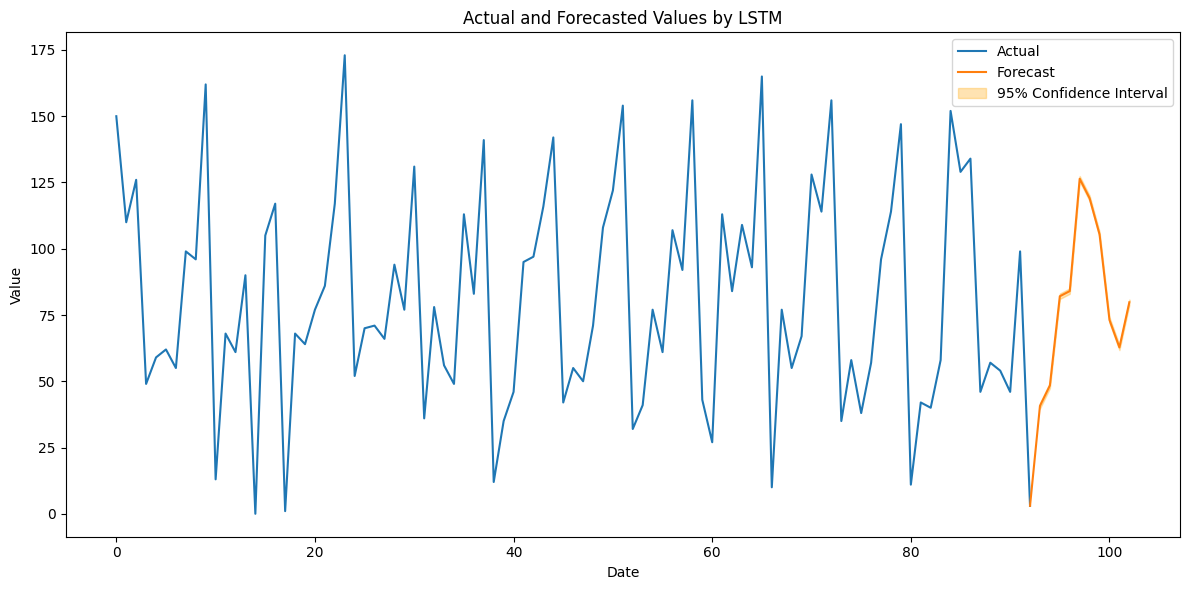


    Model       RMSE        MAE      MAPE  RMSE_Rank  MAE_Rank  MAPE_Rank  Avg_Rank
2    LSTM   0.532892   0.406390  0.007769        1.0       1.0        1.0       1.0
0   ARIMA  25.786353  18.077739  0.893752        2.0       2.0        2.0       2.0
1  SARIMA  31.027886  20.536801  0.918808        3.0       3.0        3.0       3.0

Best model: LSTM


LSTM


In [4]:
# Then define the types of analysis you want to perform

arima= ARIMA(processed_data, verbose=verbose, log_filename=log_filename)
sarima = SARIMA(processed_data, verbose=verbose)
lstm = LSTM(processed_data, fut_pred=future_pred, train_window=10, verbose=verbose)

# Add them to the candidate model list
p1, d1, m1, = arima.run() # performance dictionary 1, data object 1, model object 1
p2, d2, m2, = sarima.run() # performance dictionary 2, data object 2, model object 2
p3, d3, m3, = lstm.run() # performance dictionary 3, data object 3, model object 3

# Store your performance and model objects
perf_dicts = [p1,p2,p3]
model_objs = [m1,m2,m3]

candidates = pd.DataFrame(perf_dicts)

# And see which model has the highest average performance on our data
best_model = Ranker(df=candidates, verbose=verbose).get_best()
print(best_model)


## Displaying Forecast Results

Once the pipeline has identified the best-performing model, this step calls a visualization utility to generate time series plots using the chosen model and the corresponding processed data. 

If ARIMA was ranked as the top model, its results are visualized.

If SARIMA was the leader, its results are visualized instead.

LSTM visualizations are included in the verbose print of the previous step to save export complexity. (If needed this can be changed to be included in this step and removed from the verbose print earlier, as I have the metadata now saved to be able to undo the scaler transformations performed in the trianing loop.)

In [5]:
# Now that we have done all that work we gotta see the final results; so call visualize.py
if best_model == 'ARIMA':
    visualize_model(m1, d1, target_col="customers",)
if best_model == 'SARIMA':
    visualize_model(m2, d2, target_col="customers",)

## Saving the Best Model for Future Use

This section ensures that the highest-performing forecasting model is serialized and all relevant metadata is logged.



In [6]:
# Serialize best model
idx = [p['performance']['Model'] for p in perf_dicts].index(best_model)
best_model_obj = model_objs[idx]
metadata = perf_dicts[idx]['metadata']

# Save Model Metedata for future reference
if perf_dicts[idx]['performance']["Model"] == "ARIMA" or perf_dicts[idx]['performance']["Model"] == "SARIMA":
    with open(f'Model Registry/{str(best_model)}.pkl', 'wb') as f:
        pickle.dump(best_model_obj, f)
    
    with open('Model Registry/example/metadata.json', 'w') as f:
        json.dump(perf_dicts[idx], f)
        
if perf_dicts[idx]['performance']["Model"] == "LSTM":
    torch.save(best_model_obj.state_dict(), "Model Registry/example/LSTM.pt")
    
    with open('Model Registry/example/metadata.json', 'w') as f:
        json.dump(perf_dicts[idx], f)

## Making Predictions with a Trained Model

This cell demonstrates how to easily use a saved model for inference.

Selecting a Model: 

Specify the path to the best-trained model (e.g., an LSTM checkpoint) for loading during inference (with the metadata.json that is saved alongside the model, important information on how to reconstruct the origional timeseries shape is perserved and can be automatically handled in infer.py).

Preparing Data: 

Define which feature (such as 'customers') will be predicted

Running Inference: 

The `infer` function takes in the processed data, target column, and path to the serialized model. It loads the model behind the scenes, applies it to the latest available data, and generates future predictions automatically (default is 10 timesteps in the future). The return is accompanied by the prediction interval of 95%, which widens as the predictions extend further in time. 

Visualizing Predictions: 

`plot_inference` overlays true historical values and the model’s forecast. This immediate visual feedback helps assess how closely the projected demand matches expected restaurant traffic, and allows decision makers to quickly interpret the quality and relevance of the model’s output.

This is basically a mirror of the plots in visualize, but shows how to do it by hand if needed.

The next 10 predictions are:
 [ 40.715164  48.42459   82.07803   84.02281  126.417046 119.04308
 105.41214   73.12106   62.78261   79.80895 ]

Predictions with 95% step associated decaying prediction interval:

Step 1: 40.72 (95% PI: [39.67, 41.76])
Step 2: 48.42 (95% PI: [46.95, 49.90])
Step 3: 82.08 (95% PI: [80.27, 83.89])
Step 4: 84.02 (95% PI: [81.93, 86.11])
Step 5: 126.42 (95% PI: [124.08, 128.75])
Step 6: 119.04 (95% PI: [116.48, 121.60])
Step 7: 105.41 (95% PI: [102.65, 108.18])
Step 8: 73.12 (95% PI: [70.17, 76.08])
Step 9: 62.78 (95% PI: [59.65, 65.92])
Step 10: 79.81 (95% PI: [76.51, 83.11])


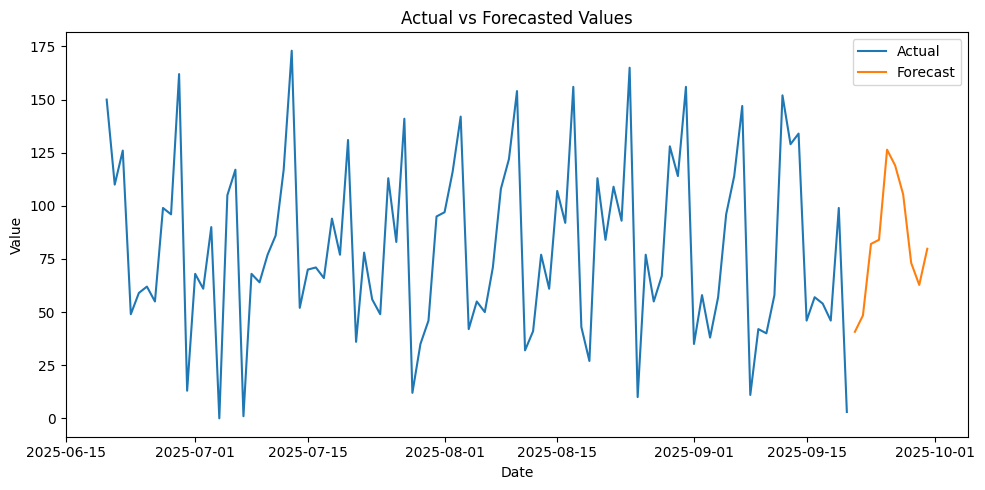

In [7]:
# Inference is as easy as this:

# Choose model
model_path = "Model Registry/example/LSTM.pt"

# Choose Targets
data = featured_data
feature_column = "customers"

# Call infer 
future_preds = infer(processed_data=processed_data, feature_column=feature_column, model_path=model_path)

# If you want to visualize these, you can run this:
plot_inference(processed_data["customers"], future_preds)

## Customizing the Target Feature for Forecasting

The pipeline is flexible and can be applied to engineered or alternative target columns besides the original 'customers' count. This cell illustrates how to re-run the pipeline using one of the previously enginered features ('customers_mean_8').

########################################
Running ARIMA Parameter Search...
########################################
Diff 0...
The p-value: 0.06713614179220807 implies the series is non-stationary and requires differencing.
--------------------
Diff 1...
Data is stationary.
--------------------
                               SARIMAX Results                                
Dep. Variable:       customers_mean_8   No. Observations:                   92
Model:                 ARIMA(6, 0, 7)   Log Likelihood                -260.522
Date:                Mon, 29 Sep 2025   AIC                            551.044
Time:                        12:00:48   BIC                            588.871
Sample:                    06-21-2025   HQIC                           566.311
                         - 09-20-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0

########################################
[90.01808  78.80116  76.16861  82.54427  79.62166  89.192215 78.204475
 85.56581  73.17273  80.08728 ]


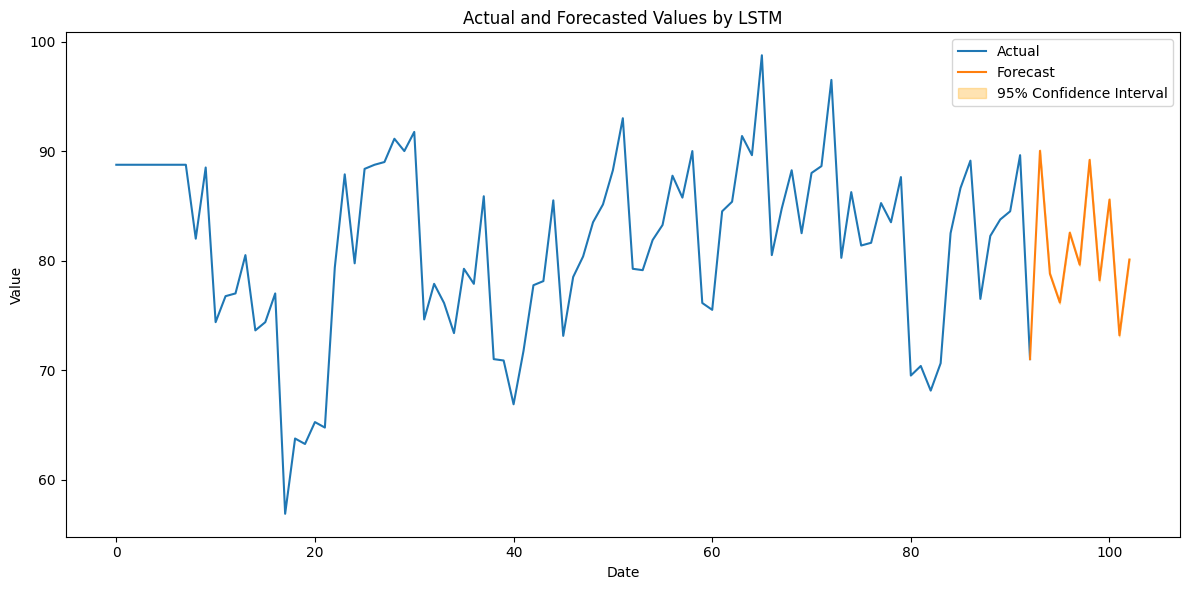


    Model      RMSE       MAE      MAPE  RMSE_Rank  MAE_Rank  MAPE_Rank  Avg_Rank
2    LSTM  0.063724  0.045904  0.000565        1.0       1.0        1.0  1.000000
0   ARIMA  4.031969  3.001698  1.584828        2.0       2.0        3.0  2.333333
1  SARIMA  4.846694  3.365585  1.276584        3.0       3.0        2.0  2.666667

Best model: LSTM


LSTM


In [8]:
# If you wanted to run on a different feature column, this is how you could do that:

data = featured_data
feature_column = "customers_mean_8"

arima= ARIMA(data, feature_column, verbose=verbose, log_filename=log_filename)
sarima = SARIMA(data, feature_column, verbose=verbose)
lstm = LSTM(data, feature_column=feature_column, fut_pred=future_pred, train_window=10, verbose=verbose)

# Add them to the candidate model list
p1, d1, m1, = arima.run() # performance dictionary 1, data object 1, model object 1
p2, d2, m2, = sarima.run() # performance dictionary 2, data object 2, model object 2
p3, d3, m3, = lstm.run() # performance dictionary 3, data object 3, model object 3

# Store your performance and model objects
perf_dicts = [p1,p2,p3]
model_objs = [m1,m2,m3]

candidates = pd.DataFrame(perf_dicts)

# And see which model has the highest average performance on our data
best_model = Ranker(df=candidates, verbose=verbose).get_best()
print(best_model)